# Tree-Based Models: Random Forest, XGBoost, LightGBM

Train and tune tree-based models for **GHR prediction** (single target).  
DLI is derived after prediction as `DLI = GHR * 0.00726460`.  
These models use one-hot encoded features (no scaling needed).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import time
import json
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore")

DATA_DIR = "../../datasets/processed"
MODEL_DIR = "../../models"
os.makedirs(MODEL_DIR, exist_ok=True)

X_train = pd.read_csv(f"{DATA_DIR}/X_train_tree.csv")
X_test = pd.read_csv(f"{DATA_DIR}/X_test_tree.csv")
y_train = pd.read_csv(f"{DATA_DIR}/y_train.csv")
y_test = pd.read_csv(f"{DATA_DIR}/y_test.csv")

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")
print(f"Target column(s): {list(y_train.columns)}")
print(f"Features: {list(X_train.columns)}")

X_train: (70080, 22), X_test: (17520, 22)
y_train: (70080, 1), y_test: (17520, 1)
Target column(s): ['GHR']
Features: ['Day_of_Year', 'Tree_Width_m', 'Tree_Present', 'Window_Transmittance', 'WWR', 'Day_sin', 'Day_cos', 'Season_sin', 'Season_cos', 'Ori_E', 'Ori_N', 'Ori_NE', 'Ori_NW', 'Ori_S', 'Ori_SE', 'Ori_W', 'Lvl_G', 'Lvl_M', 'Lvl_U', 'Effective_Transmittance', 'WWR_x_Transmittance', 'Tree_Effect']


In [2]:
DLI_RATIO = 0.00726460

def compute_metrics(y_true, y_pred):
    """Compute regression metrics for a single target."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    return {"RMSE": rmse, "MAE": mae, "R2": r2, "MAPE": mape}

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """Evaluate on both train and test sets."""
    y_pred_train = model.predict(X_train).flatten()
    y_pred_test = model.predict(X_test).flatten()
    yt_train = y_train.values.flatten()
    yt_test = y_test.values.flatten()

    train_metrics = compute_metrics(yt_train, y_pred_train)
    test_metrics = compute_metrics(yt_test, y_pred_test)

    print(f"  {'':12s} {'RMSE':>10s} {'MAE':>10s} {'R²':>10s} {'MAPE(%)':>10s}")
    print(f"  {'Train GHR':12s} {train_metrics['RMSE']:10.4f} {train_metrics['MAE']:10.4f} {train_metrics['R2']:10.6f} {train_metrics['MAPE']:10.2f}")
    print(f"  {'Test GHR':12s} {test_metrics['RMSE']:10.4f} {test_metrics['MAE']:10.4f} {test_metrics['R2']:10.6f} {test_metrics['MAPE']:10.2f}")
    
    gap = train_metrics["R2"] - test_metrics["R2"]
    print(f"  Train-Test R² gap: {gap:.6f} {'(OK)' if gap < 0.01 else '(potential overfitting!)'}")

    return {
        "train": {"GHR": train_metrics, "DLI_derived": {**train_metrics, "RMSE": train_metrics["RMSE"]*DLI_RATIO, "MAE": train_metrics["MAE"]*DLI_RATIO}},
        "test":  {"GHR": test_metrics, "DLI_derived": {**test_metrics, "RMSE": test_metrics["RMSE"]*DLI_RATIO, "MAE": test_metrics["MAE"]*DLI_RATIO}},
    }

all_results = {}

## 1. Random Forest

In [3]:
print("Training Random Forest...")
t0 = time.time()

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train.values.flatten())
train_time_rf = time.time() - t0
print(f"Training time: {train_time_rf:.1f}s")

t0 = time.time()
for _ in range(10):
    rf.predict(X_test.iloc[:1])
inference_ms_rf = (time.time() - t0) / 10 * 1000
print(f"Single inference: {inference_ms_rf:.2f}ms\n")

all_results["RandomForest"] = evaluate_model(rf, X_train, y_train, X_test, y_test, "RandomForest")
all_results["RandomForest"]["train_time"] = train_time_rf
all_results["RandomForest"]["inference_ms"] = inference_ms_rf

joblib.dump(rf, f"{MODEL_DIR}/random_forest.pkl")

Training Random Forest...


Training time: 1.0s
Single inference: 16.13ms



                     RMSE        MAE         R²    MAPE(%)
  Train GHR      156.4748    76.1603   0.974747      12.70
  Test GHR       245.0616   117.7467   0.938983      19.39
  Train-Test R² gap: 0.035764 (potential overfitting!)


['../../models/random_forest.pkl']

## 2. XGBoost

In [4]:
print("Training XGBoost...")
t0 = time.time()

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=42,
    tree_method="hist"
)

xgb_model.fit(X_train, y_train.values.flatten())
train_time_xgb = time.time() - t0
print(f"Training time: {train_time_xgb:.1f}s")

t0 = time.time()
for _ in range(10):
    xgb_model.predict(X_test.iloc[:1])
inference_ms_xgb = (time.time() - t0) / 10 * 1000
print(f"Single inference: {inference_ms_xgb:.2f}ms\n")

all_results["XGBoost"] = evaluate_model(xgb_model, X_train, y_train, X_test, y_test, "XGBoost")
all_results["XGBoost"]["train_time"] = train_time_xgb
all_results["XGBoost"]["inference_ms"] = inference_ms_xgb

joblib.dump(xgb_model, f"{MODEL_DIR}/xgboost.pkl")

Training XGBoost...


Training time: 0.9s
Single inference: 1.04ms

                     RMSE        MAE         R²    MAPE(%)
  Train GHR       72.5968    45.6535   0.994564      11.80
  Test GHR        85.0697    51.2061   0.992647      12.85
  Train-Test R² gap: 0.001917 (OK)


['../../models/xgboost.pkl']

## 3. LightGBM

In [5]:
print("Training LightGBM...")
t0 = time.time()

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=42,
    verbose=-1
)

lgb_model.fit(X_train, y_train.values.flatten())
train_time_lgb = time.time() - t0
print(f"Training time: {train_time_lgb:.1f}s")

t0 = time.time()
for _ in range(10):
    lgb_model.predict(X_test.iloc[:1])
inference_ms_lgb = (time.time() - t0) / 10 * 1000
print(f"Single inference: {inference_ms_lgb:.2f}ms\n")

all_results["LightGBM"] = evaluate_model(lgb_model, X_train, y_train, X_test, y_test, "LightGBM")
all_results["LightGBM"]["train_time"] = train_time_lgb
all_results["LightGBM"]["inference_ms"] = inference_ms_lgb

joblib.dump(lgb_model, f"{MODEL_DIR}/lightgbm.pkl")

Training LightGBM...


Training time: 0.8s
Single inference: 0.32ms

                     RMSE        MAE         R²    MAPE(%)
  Train GHR      156.8696    96.5111   0.974619      23.05
  Test GHR       165.5584    99.9957   0.972151      23.91
  Train-Test R² gap: 0.002468 (OK)


['../../models/lightgbm.pkl']

## 4. Feature Importance (Best Tree Model)

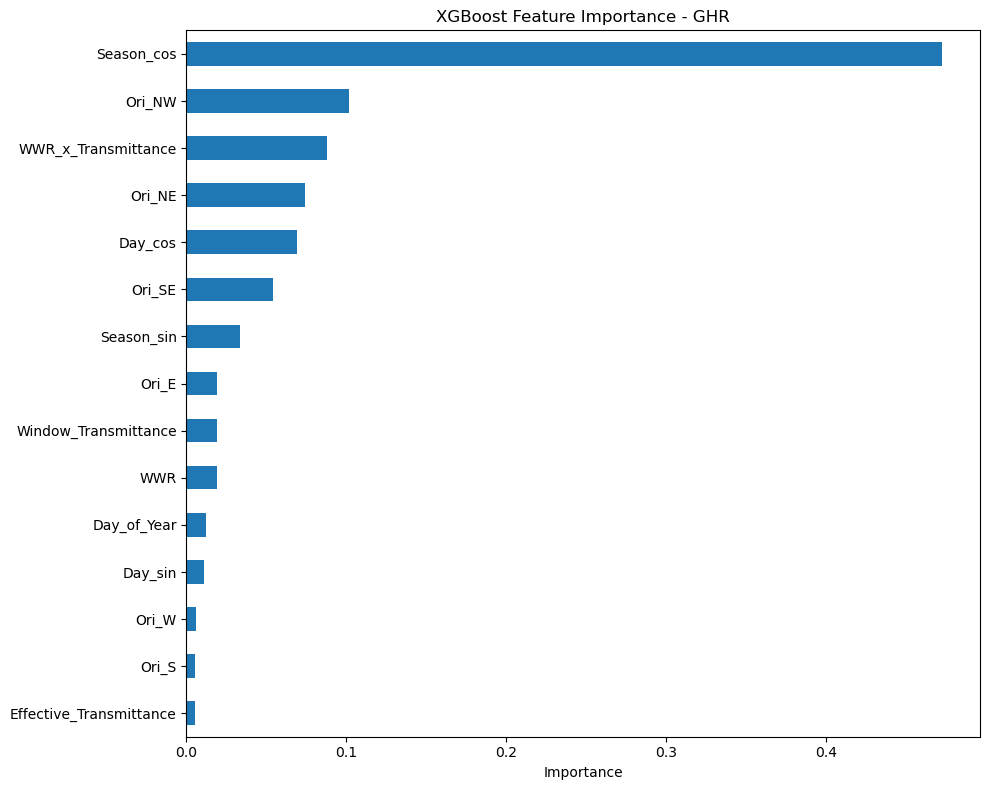

In [6]:
# Feature importance from XGBoost (single GHR target)
fig, ax = plt.subplots(figsize=(10, 8))

importances = xgb_model.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=True)
feat_imp.tail(15).plot(kind="barh", ax=ax)
ax.set_title("XGBoost Feature Importance - GHR")
ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

## 5. Tree Models Summary

In [7]:
# Summary table: Train vs Test
rows = []
for name, res in all_results.items():
    for split in ["train", "test"]:
        rows.append({
            "Model": name,
            "Split": split.upper(),
            "GHR_RMSE": round(res[split]["GHR"]["RMSE"], 2),
            "GHR_MAE": round(res[split]["GHR"]["MAE"], 2),
            "GHR_R²": round(res[split]["GHR"]["R2"], 6),
            "GHR_MAPE(%)": round(res[split]["GHR"]["MAPE"], 2),
            "Train(s)": round(res["train_time"], 1),
            "Inference(ms)": round(res["inference_ms"], 2)
        })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

# Overfitting check
print("\n--- Overfitting Check (Train R² - Test R²) ---")
for name, res in all_results.items():
    gap = res["train"]["GHR"]["R2"] - res["test"]["GHR"]["R2"]
    print(f"  {name:15s}: gap = {gap:.6f} {'✓' if gap < 0.01 else '⚠ overfitting'}")

# Save results for comparison notebook
with open(f"{MODEL_DIR}/tree_results.json", "w") as f:
    json.dump(all_results, f, indent=2)
print(f"\nResults saved to {MODEL_DIR}/tree_results.json")

       Model Split  GHR_RMSE  GHR_MAE   GHR_R²  GHR_MAPE(%)  Train(s)  Inference(ms)
RandomForest TRAIN    156.47    76.16 0.974747        12.70       1.0          16.13
RandomForest  TEST    245.06   117.75 0.938983        19.39       1.0          16.13
     XGBoost TRAIN     72.60    45.65 0.994564        11.80       0.9           1.04
     XGBoost  TEST     85.07    51.21 0.992647        12.85       0.9           1.04
    LightGBM TRAIN    156.87    96.51 0.974619        23.05       0.8           0.32
    LightGBM  TEST    165.56   100.00 0.972151        23.91       0.8           0.32

--- Overfitting Check (Train R² - Test R²) ---
  RandomForest   : gap = 0.035764 ⚠ overfitting
  XGBoost        : gap = 0.001917 ✓
  LightGBM       : gap = 0.002468 ✓

Results saved to ../../models/tree_results.json
